# 3.Intelligent Medical Report Understanding System
(Healthcare NLP)

Dataset
## **Medical Transcriptions Dataset**

**Project Goal**
- Analyze doctor reports and classify medical specialties.

Examples:
- Cardiology
- Neurology
- Orthopedics
- Radiology
- Dermatology

In [1]:
import pandas as pd
import kagglehub
import os

# Download dataset
path = kagglehub.dataset_download("tboyle10/medicaltranscriptions")

print(path)

C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\rakes\.cache\kagglehub\datasets\tboyle10\medicaltranscriptions\versions\1


In [2]:
csv_path = os.path.join(path, "mtsamples.csv")

df = pd.read_csv(csv_path)

print(df.head())

   Unnamed: 0                                        description  \
0           0   A 23-year-old white female presents with comp...   
1           1           Consult for laparoscopic gastric bypass.   
2           2           Consult for laparoscopic gastric bypass.   
3           3                             2-D M-Mode. Doppler.     
4           4                                 2-D Echocardiogram   

             medical_specialty                                sample_name  \
0         Allergy / Immunology                         Allergic Rhinitis    
1                   Bariatrics   Laparoscopic Gastric Bypass Consult - 2    
2                   Bariatrics   Laparoscopic Gastric Bypass Consult - 1    
3   Cardiovascular / Pulmonary                    2-D Echocardiogram - 1    
4   Cardiovascular / Pulmonary                    2-D Echocardiogram - 2    

                                       transcription  \
0  SUBJECTIVE:,  This 23-year-old white female pr...   
1  PAST MEDICAL 

In [3]:
print(df.shape)

print(df.columns)

print(df.isnull().sum())

(4999, 6)
Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')
Unnamed: 0              0
description             0
medical_specialty       0
sample_name             0
transcription          33
keywords             1068
dtype: int64


In [4]:
# Remove Missing Values

df = df[['medical_specialty', 'transcription']]

df.dropna(inplace=True)

print(df.shape)

(4966, 2)


## **Task 1: Medical Text Analysis**
Find:
- Number of reports
- Specialty distribution
- Most common medical terms

In [5]:
print("Total Reports:", len(df))

Total Reports: 4966


medical_specialty
Surgery                          1088
Consult - History and Phy.        516
Cardiovascular / Pulmonary        371
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  224
Neurology                         223
SOAP / Chart / Progress Notes     166
Urology                           156
Obstetrics / Gynecology           155
Discharge Summary                 108
ENT - Otolaryngology               96
Neurosurgery                       94
Hematology - Oncology              90
Ophthalmology                      83
Nephrology                         81
Emergency Room Reports             75
Pediatrics - Neonatal              70
Pain Management                    61
Name: count, dtype: int64


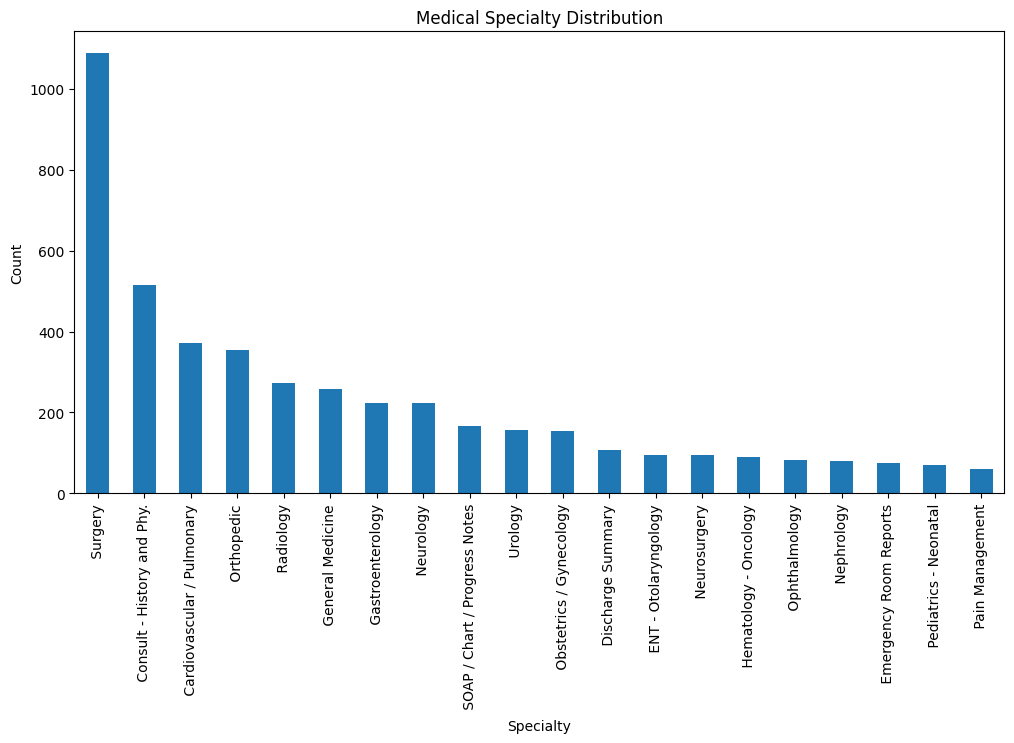

In [6]:
# Specialty Distribution

import matplotlib.pyplot as plt

specialty_counts = df['medical_specialty'].value_counts()

print(specialty_counts.head(20))

plt.figure(figsize=(12,6))
specialty_counts.head(20).plot(kind='bar')
plt.title("Medical Specialty Distribution")
plt.xlabel("Specialty")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [7]:
# Text Cleaning

import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df['clean_text'] = df['transcription'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\rakes\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# Most Common Medical Terms

from collections import Counter

all_words = " ".join(df['clean_text']).split()

word_freq = Counter(all_words)

print(word_freq.most_common(50))

[('patient', 21920), ('right', 11137), ('left', 10776), ('history', 8264), ('placed', 6962), ('normal', 6804), ('well', 5883), ('pain', 5491), ('procedure', 5077), ('also', 4317), ('mg', 4191), ('using', 4060), ('time', 3917), ('noted', 3885), ('performed', 3845), ('blood', 3823), ('without', 3730), ('incision', 3557), ('used', 3519), ('removed', 3486), ('skin', 3433), ('room', 3429), ('diagnosis', 3132), ('x', 2965), ('artery', 2926), ('anterior', 2898), ('yearold', 2845), ('taken', 2805), ('back', 2544), ('dr', 2533), ('position', 2517), ('area', 2477), ('mm', 2461), ('lower', 2442), ('two', 2390), ('cm', 2341), ('made', 2338), ('fashion', 2327), ('upper', 2321), ('disease', 2318), ('anesthesia', 2312), ('one', 2287), ('closed', 2265), ('chest', 2262), ('pressure', 2222), ('good', 2222), ('posterior', 2214), ('general', 2193), ('patients', 2193), ('present', 2183)]


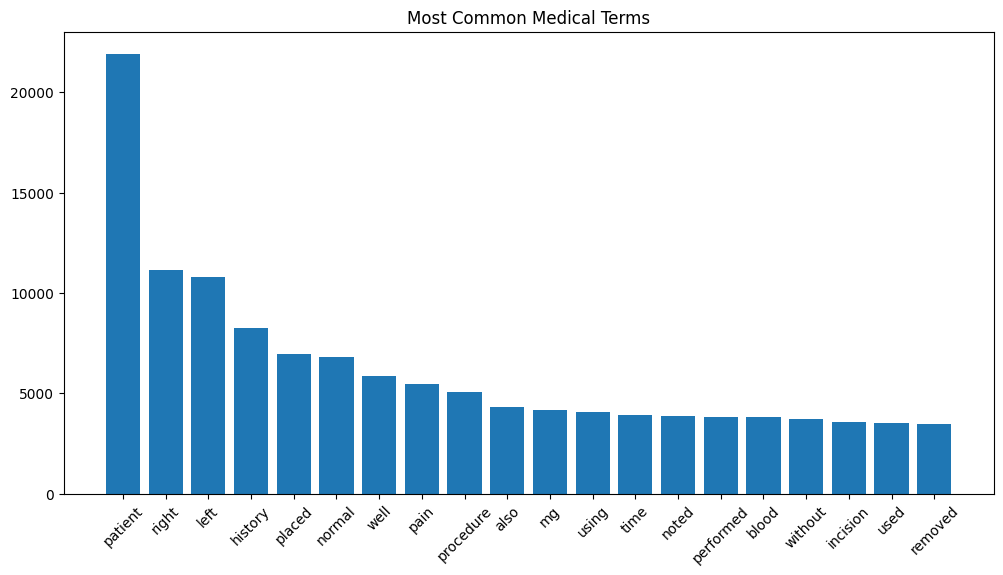

In [9]:
# Word Frequency Visualization

common_words = word_freq.most_common(20)

words = [x[0] for x in common_words]
counts = [x[1] for x in common_words]

plt.figure(figsize=(12,6))
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Most Common Medical Terms")
plt.show()

## **Task 2: Medical Vocabulary Builder**
Create:
- Medical Term Dictionary
- with frequency.

In [10]:
medical_vocab = dict(word_freq)

print(list(medical_vocab.items())[:20])

[('subjective', 253), ('yearold', 2845), ('white', 1078), ('female', 1448), ('presents', 503), ('complaint', 664), ('allergies', 213), ('used', 3519), ('lived', 26), ('seattle', 8), ('thinks', 81), ('worse', 316), ('past', 1305), ('tried', 148), ('claritin', 48), ('zyrtec', 54), ('worked', 175), ('short', 309), ('time', 3917), ('seemed', 155)]


In [11]:
import json

with open("medical_vocab.json", "w") as f:
    json.dump(medical_vocab, f)

In [12]:
top_terms = sorted(
    medical_vocab.items(),
    key=lambda x: x[1],
    reverse=True
)

print(top_terms[:50])

[('patient', 21920), ('right', 11137), ('left', 10776), ('history', 8264), ('placed', 6962), ('normal', 6804), ('well', 5883), ('pain', 5491), ('procedure', 5077), ('also', 4317), ('mg', 4191), ('using', 4060), ('time', 3917), ('noted', 3885), ('performed', 3845), ('blood', 3823), ('without', 3730), ('incision', 3557), ('used', 3519), ('removed', 3486), ('skin', 3433), ('room', 3429), ('diagnosis', 3132), ('x', 2965), ('artery', 2926), ('anterior', 2898), ('yearold', 2845), ('taken', 2805), ('back', 2544), ('dr', 2533), ('position', 2517), ('area', 2477), ('mm', 2461), ('lower', 2442), ('two', 2390), ('cm', 2341), ('made', 2338), ('fashion', 2327), ('upper', 2321), ('disease', 2318), ('anesthesia', 2312), ('one', 2287), ('closed', 2265), ('chest', 2262), ('pressure', 2222), ('good', 2222), ('posterior', 2214), ('general', 2193), ('patients', 2193), ('present', 2183)]


## **Task 3: Baseline Model**

|Embedding|
|---------|
|↓|
|Dense|
|↓|
|Output|

In [13]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['label'] = encoder.fit_transform(df['medical_specialty'])

In [14]:
# Tokenization

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 20000
MAX_LEN = 200

tokenizer = Tokenizer(num_words=MAX_WORDS)

tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])

X = pad_sequences(X, maxlen=MAX_LEN)

y = df['label']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Baseline Model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling1D

VOCAB_SIZE = 20000
EMBED_DIM = 128

baseline_model = Sequential([

    Embedding(VOCAB_SIZE, EMBED_DIM, input_length=MAX_LEN),

    GlobalAveragePooling1D(),

    Dense(128, activation='relu'),

    Dense(len(encoder.classes_), activation='softmax')
])

baseline_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

baseline_model.summary()

C:\Users\rakes\AppData\Roaming\Python\Python310\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
history = baseline_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.2394 - loss: 3.0471 - val_accuracy: 0.3471 - val_loss: 2.6334
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.3293 - loss: 2.5109 - val_accuracy: 0.3441 - val_loss: 2.4137
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3565 - loss: 2.2578 - val_accuracy: 0.3501 - val_loss: 2.2736
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.3749 - loss: 2.0442 - val_accuracy: 0.3280 - val_loss: 2.1644
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3882 - loss: 1.8596 - val_accuracy: 0.2978 - val_loss: 2.1232
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3993 - loss: 1.7019 - val_accuracy: 0.2565 - val_loss: 2.1038
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4333 - loss: 1.5653 - val_accuracy: 0.2324 - val_loss: 2.1194
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - accuracy: 0.4496 - loss: 1.4474 - val_accu

## **Task 4: Self-Attention Model**

|Embedding|
|---------|
|↓|
|MultiHeadAttention|
|↓|
|Output|

In [18]:
# Attention Model

import tensorflow as tf
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.layers import LayerNormalization
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.models import Model

inputs = Input(shape=(MAX_LEN,))

x = Embedding(VOCAB_SIZE, 128)(inputs)

attention_output = MultiHeadAttention(
    num_heads=4,
    key_dim=128
)(x, x)

x = LayerNormalization()(attention_output)

x = GlobalAveragePooling1D()(x)

x = Dense(128, activation='relu')(x)

outputs = Dense(
    len(encoder.classes_),
    activation='softmax'
)(x)

attention_model = Model(inputs, outputs)

attention_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

attention_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 200, 128)  │  2,560,000 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 128)  │    263,808 │ embedding_1[0][0… │
│ (MultiHeadAttentio… │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 200, 128)  │        256 │ multi_head_atten… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     16,512 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 40)        │      5,160 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,845,736 (10.86 MB)

 Trainable params: 2,845,736 (10.86 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
history2 = attention_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 205ms/step - accuracy: 0.2938 - loss: 2.6256 - val_accuracy: 0.3541 - val_loss: 2.1983
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 26s 211ms/step - accuracy: 0.3600 - loss: 1.8904 - val_accuracy: 0.3018 - val_loss: 1.9578
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 25s 202ms/step - accuracy: 0.4033 - loss: 1.5050 - val_accuracy: 0.2535 - val_loss: 1.9846
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.4418 - loss: 1.3021 - val_accuracy: 0.1932 - val_loss: 2.2500
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 174ms/step - accuracy: 0.4532 - loss: 1.1701 - val_accuracy: 0.1891 - val_loss: 2.4262
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 176ms/step - accuracy: 0.4680 - loss: 1.0945 - val_accuracy: 0.1489 - val_loss: 2.4398
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 21s 164ms/step - accuracy: 0.4617 - loss: 1.0540 - val_accuracy: 0.1117 - val_loss: 2.7297
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 162ms/step - accuracy: 0.4655 - loss: 0

## **Task 5: Positional Encoding**
**Implement from scratch.**

Visualize:
- Sentence Position
- Token Position

In [20]:
import numpy as np

def positional_encoding(max_len, d_model):

    pe = np.zeros((max_len, d_model))

    for pos in range(max_len):

        for i in range(0, d_model, 2):

            pe[pos, i] = np.sin(
                pos / (10000 ** ((2 * i)/d_model))
            )

            if i + 1 < d_model:

                pe[pos, i+1] = np.cos(
                    pos / (10000 ** ((2 * i)/d_model))
                )

    return pe

PE = positional_encoding(200, 128)

print(PE.shape)

(200, 128)


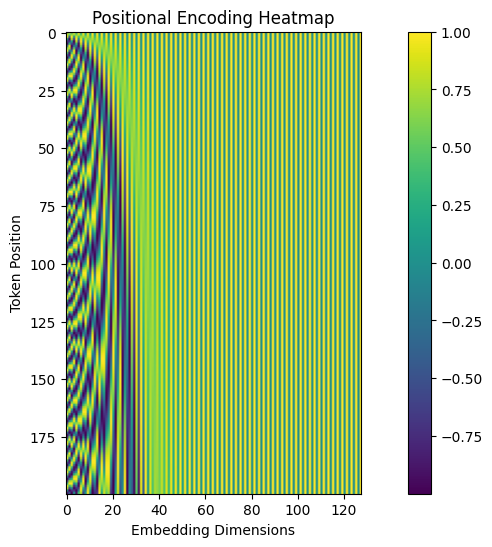

In [21]:
plt.figure(figsize=(12,6))

plt.imshow(PE)

plt.colorbar()

plt.title("Positional Encoding Heatmap")

plt.xlabel("Embedding Dimensions")

plt.ylabel("Token Position")

plt.show()

In [22]:
x = Embedding(VOCAB_SIZE, 128)(inputs)

x = x + tf.cast(PE, dtype=tf.float32)

## **Task 6: Diagnostic Importance Analysis**
Find:
- Which words influenced diagnosis prediction?

Example:
- stroke
- fracture
- tumor
- infection


In [23]:
attention_layer = MultiHeadAttention(
    num_heads=4,
    key_dim=128
)

attention_output, scores = attention_layer(
    x,
    x,
    return_attention_scores=True
)

In [24]:
attention_extractor = Model(
    inputs=inputs,
    outputs=scores
)

In [25]:
sample = X_test[0:1]

attention_scores = attention_extractor.predict(sample)

print(attention_scores.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
(1, 4, 200, 200)


In [26]:
reverse_word_index = {
    v:k for k,v in tokenizer.word_index.items()
}

tokens = sample[0]

words = []

for token in tokens:

    if token != 0:
        words.append(
            reverse_word_index.get(token, "UNK")
        )

print(words)

['compazine', 'zofran', 'prn', 'examination', 'general', 'alert', 'frustrated', 'prolonged', 'hospital', 'stay', 'notes', 'epistaxis', 'days', 'ago', 'requiring', 'nasal', 'packing', 'fortunately', 'resolved', 'signs', 'today', 'temperature', 'pulse', 'respirations', 'blood', 'pressure', 'pulse', 'requiring', 'significant', 'ecchymoses', 'notedabdomen', 'ileostomy', 'place', 'greenish', 'black', 'liquid', 'output', 'midline', 'surgical', 'scar', 'healed', 'well', 'dressing', 'place', 'middle', 'bleeding', 'notedextremities', 'peripheral', 'regular', 'adenopathy', 'notedlungs', 'clear', 'bilaterallyimpression', 'plan', 'markedly', 'elevated', 'ptinr', 'despite', 'stopping', 'coumadin', 'administering', 'vitamin', 'k', 'check', 'mixing', 'studies', 'see', 'deficiency', 'could', 'due', 'poor', 'production', 'given', 'elevated', 'lfts', 'decreased', 'albumin', 'decreased', 'possible', 'inhibitor', 'would', 'acquired', 'inhibitor', 'generally', 'presenting', 'elevated', 'ptt', 'pt', 'check'

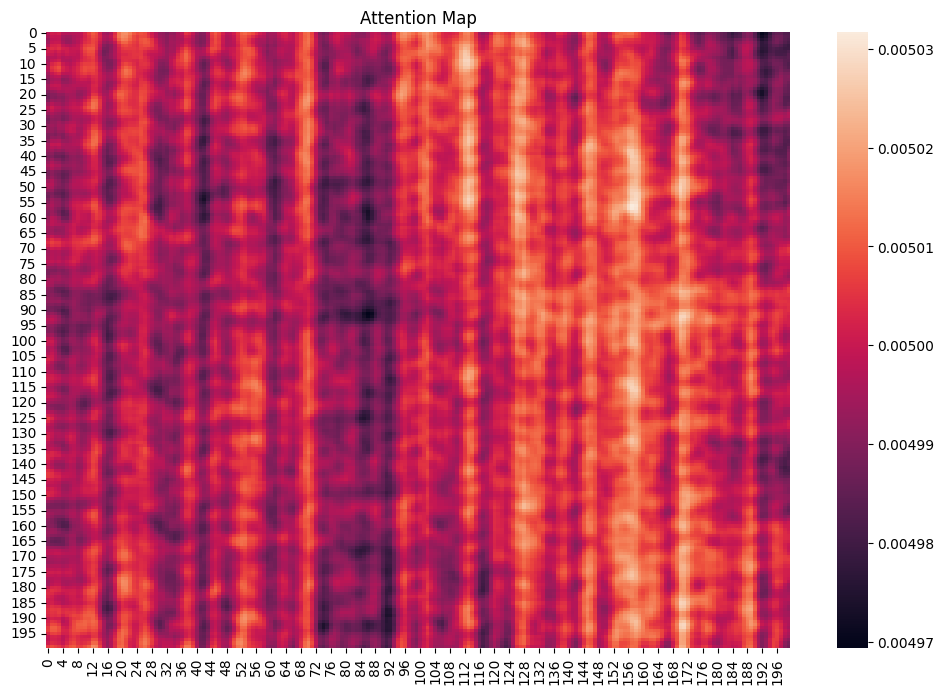

In [27]:
import seaborn as sns

scores_mean = attention_scores.mean(axis=1)[0]

plt.figure(figsize=(12,8))

sns.heatmap(scores_mean)

plt.title("Attention Map")

plt.show()

In [28]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved")

Tokenizer saved


In [29]:
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

print("Label Encoder saved")    

Label Encoder saved


In [30]:
attention_model.save("attention_model.keras")

print("Model saved")

Model saved


In [31]:
import os

print(os.listdir())

['.gitignore', 'app.py', 'assignment3.ipynb', 'attention_model.keras', 'label_encoder.pkl', 'medical_vocab.json', 'requirements.txt', 'tokenizer.pkl']


## **Task 7: Explainable Healthcare Dashboard**
**Upload Medical Report**

Display:
- Specialty Prediction
- Confidence Score
- Attention Map
- Positional Encoding Heatmap

Bonus
- Generate PDF Medical Analysis Report.


MRI of the brain revealed a small ischemic stroke in the left parietal lobe. The patient reports dizziness, weakness, and slurred speech.

The patient is a 65-year-old male presenting with chest pain radiating to the left arm. ECG showed ST elevation. Troponin levels were elevated. Diagnosis suggests acute myocardial infarction.

X-ray examination showed a fracture of the distal radius with mild displacement. The patient complains of severe wrist pain and swelling.

CT scan demonstrates a tumor in the frontal lobe with surrounding edema. Surgical consultation is recommended.